<a href="https://colab.research.google.com/github/crisriverar/ConnectaTel/blob/main/ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

El objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello se trabajará con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

---
### Paso 1: Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean().sort_values(ascending=False))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean().sort_values(ascending=False))

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

In [ ]:
# explorar columnas numéricas de users
users[["user_id","age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
# explorar columnas numéricas de users
users['age'].isin([-999]).sum()

55

- La columna `user_id`no presenta problemas en los datos
- La columna `age`tiene 55 regitros invalidos -999

In [ ]:
# explorar columnas numéricas de usage
usage[["id","user_id"]].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id` no presenta problemas en los datos son los identificadores de registro

In [ ]:
# explorar columnas categóricas de users
users[['city', 'plan']].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` contiene 96 valores invalidos ?
- La columna `plan` no presenta problemas en los datos

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`no presenta problemas en los datos

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`,solo tenemos 2024, sin fechas invalidas
Basaremos el análisis en estas fechas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.


In [ ]:
# Reemplazar -999 por la mediana de age
users['age'] = users["age"].replace([-999],pd.NA)
users['age'] = users["age"].fillna(users["age"].median())
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"]= users["city"].replace(["?"],pd.NA)

# Verificar cambios
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:


# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026,"reg_date"]=pd.NaT
# Verificar cambios
users['reg_date'].dt.year.value_counts()


2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.


In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Diagnostico de nulos en `duration` y `length`
duration y length son MAR porque dependen completamente del tipo de comunicación, es pertinente dejarlos como nulos porque no son datos perdidos representan la naturaleza de cada tipi de comunicacion

---

## Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg.columns = ["user_id", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg,on=["user_id"], how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:

# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)


Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.


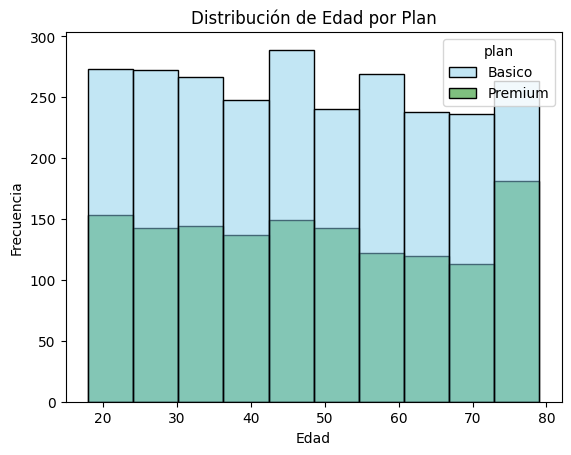

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", bins=10, palette=["skyblue","green"])
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La distribución es relativamente uniforme, aunque hay un ligero incremento de los planes premium para el sector de edades superiores a los 80.

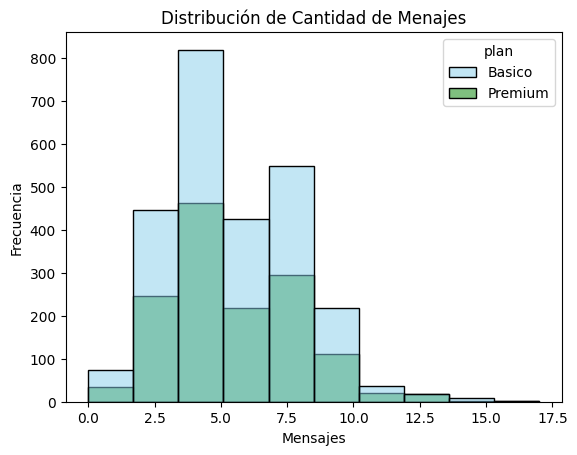

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", bins=10, palette=["skyblue","green"])
plt.title('Distribución de Cantidad de Menajes')
plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- El plan Premium muestra más frecuencia en valores ligeramente más alto y hay pocos usuarios con valores muy altos (cola derecha)

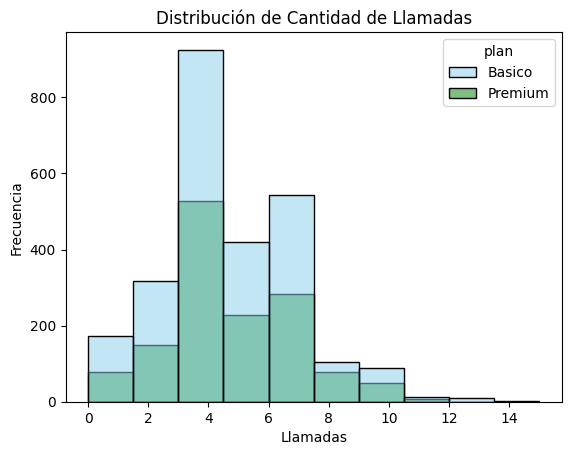

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", bins=10, palette=["skyblue","green"])
plt.title('Distribución de Cantidad de Llamadas')
plt.xlabel('Llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- Distribución es similiar entre los planes Basico y Premium, se evidencia una ligera cola a la derecha para usuarios con alta numero de llamadas

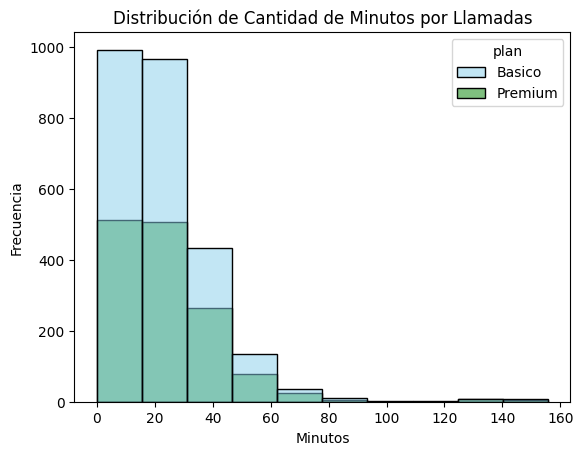

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", bins=10, palette=["skyblue","green"])
plt.title('Distribución de Cantidad de Minutos por Llamadas')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Existe una cola fuerte mente sesgada con algunos usuarios con uso muy alto a partir de los 90 minutos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

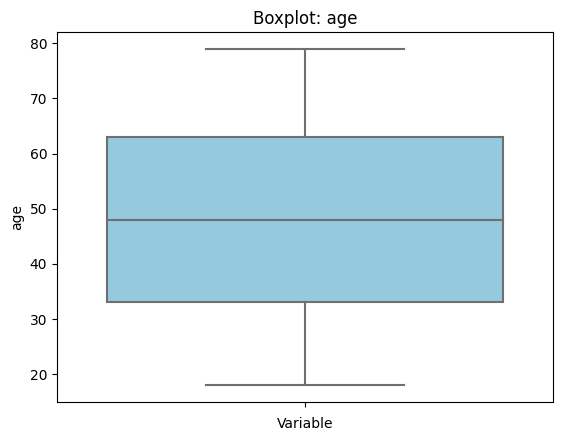

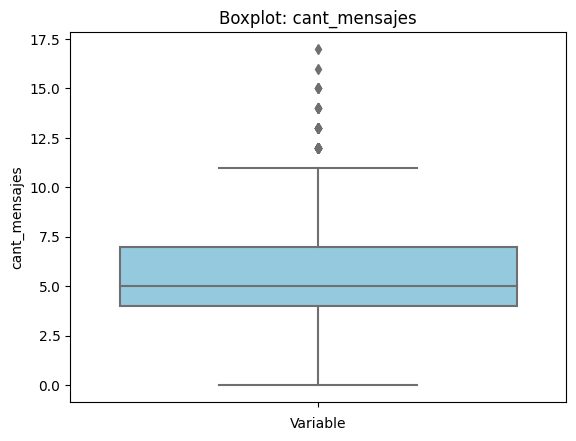

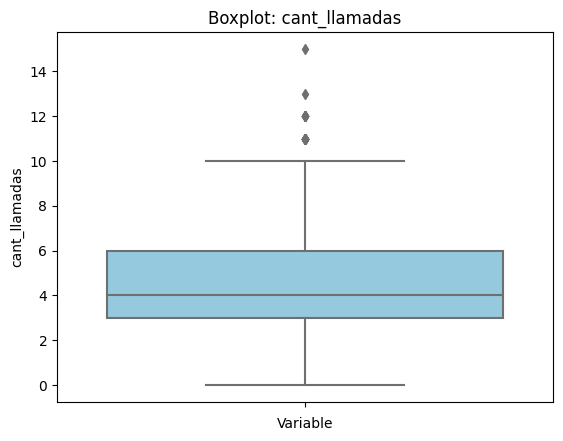

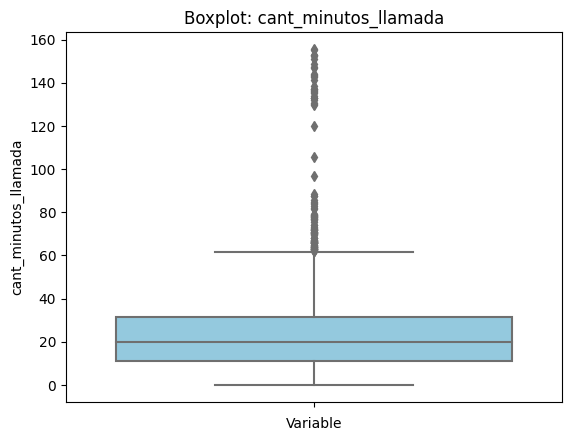

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, y=col, color='skyblue')

    plt.title(f'Boxplot: {col}')
    plt.xlabel('Variable')
    plt.ylabel(col)

    plt.show()


💡Insights:
- Age: No
- cant_mensajes: Si
- cant_llamadas: Si
- cant_minutos_llamada: Si

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR =Q3-Q1
    limite_inferior=Q1-1.5*IQR
    limite_superior=Q3+1.5*IQR

    print(f"\n{col}:")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Valor máximo en datos: {user_profile[col].max():.2f}")




cant_mensajes:
Q1: 4.00
Q3: 7.00
Límite inferior: -0.50
Límite superior: 11.50
Valor máximo en datos: 17.00

cant_llamadas:
Q1: 3.00
Q3: 6.00
Límite inferior: -1.50
Límite superior: 10.50
Valor máximo en datos: 15.00

cant_minutos_llamada:
Q1: 11.12
Q3: 31.41
Límite inferior: -19.32
Límite superior: 61.86
Valor máximo en datos: 155.69


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Mantiene: El valor máximo de 17 mensajes puede estar representando un comportamiento en los usuarios posible y no esta tan alejado del límite superior
- cant_llamadas: Mantiene: Puede represar el comportamiento de algunos usuarios, no se aleja tanto del límite superior, no parece ser un error de documentación  
- cant_minutos_llamada:Se windsorizan: El valor máximo 155 se aleja bastante del limite superior, pero puede ser un comportamiento real pero atipico, moderarlo puede reflejar mejor su impacto sin sesgar los datos

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.


In [ ]:
# Crear columna grupo_uso

def segmentacio_uso (row):

    usuario= row["user_id"]
    llamada= row["cant_llamadas"]
    mensaje= row["cant_mensajes"]

    if pd.isna(usuario) or pd.isna(llamada) or pd.isna(mensaje):
        return "Error"

    if  llamada <5:
        if mensaje < 5:
            return 'Bajo uso'
        else:
            return 'Alto uso'

    if  llamada <10:
        if mensaje < 10:
            return 'Uso medio'
        else:
            return 'Alto uso'

user_profile["grupo_uso"]= user_profile.apply(segmentacio_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Alto uso
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,None
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Alto uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.


In [ ]:
# Crear columna grupo_edad

def segmentacion_edad(row):
    edad = row["age"]

    if pd.isna(edad):
        return "Error"

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile["grupo_edad"] = user_profile.apply(segmentacion_edad, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Alto uso,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,None,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Alto uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.


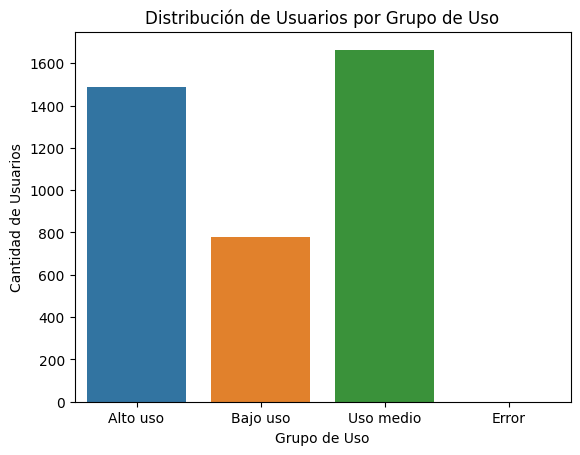

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title ("Distribución de Usuarios por Grupo de Uso")
plt.xlabel ("Grupo de Uso")
plt.ylabel ("Cantidad de Usuarios")
plt.show()

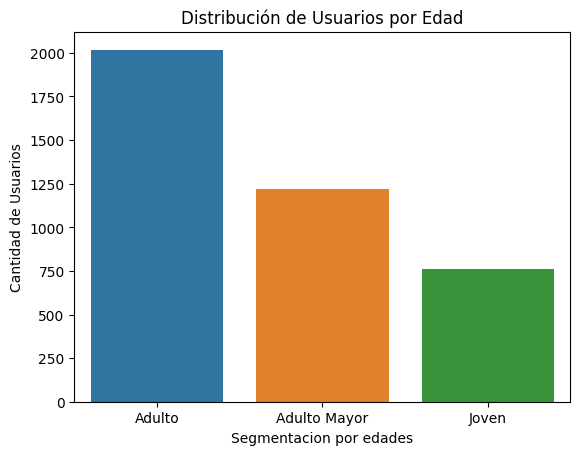

In [ ]:

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title ("Distribución de Usuarios por Edad")
plt.xlabel ("Segmentacion por edades")
plt.ylabel ("Cantidad de Usuarios")
plt.show()


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron columnas con valores faltantes, lo que podría afectar la calidad del análisis y requerir procesos de limpieza o imputación de datos.
- Se detectaron valores centinela y registros inconsistentes, particularmente en fechas y edades que no correspondían a valores plausibles, lo que indicaba posibles errores en la captura o almacenamiento de los datos.
- Algunas columnas de fecha presentaban inconsistencias en el formato, lo que dificultaba su correcta interpretación y análisis temporal, requiriendo estandarización para su correcto procesamiento.

🔍 **Segmentos por Edad**
- El análisis muestra que el segmento de adultos concentra el mayor nivel de uso del servicio, lo que sugiere que este grupo representa uno de los principales clientes potenciales para campañas orientadas a la migración hacia planes premium. Su nivel de actividad indica una mayor dependencia del servicio, lo que aumenta la probabilidad de adopción de planes con mayores beneficios.
- Aunque el segmento de adultos mayores representa aproximadamente la mitad del tamaño del grupo de adultos, continúa siendo un segmento relevante. En muchos casos, estos usuarios pueden contar con mayor estabilidad económica, por lo que desarrollar estrategias de fidelización y propuestas de valor orientadas a planes premium podría resultar efectivo para incrementar su contribución al ingreso.

📊 **Segmentos por Nivel de Uso**
- El segmento de uso medio agrupa a los clientes con un consumo regular del servicio, representando el comportamiento típico de la mayoría de los usuarios.
- El bajo nivel de uso observado en el segmento joven podría estar influenciado por una limitación en las variables analizadas. En este caso, el análisis se centra en llamadas y mensajes, sin considerar el consumo de datos móviles, que suele ser el principal canal de comunicación en usuarios más jóvenes. Esto podría estar generando una subestimación del nivel real de uso en este grupo.

➡️ Esto sugiere que ...

- Los usuarios de alto uso, particularmente dentro del segmento de adultos, parecen ser los más valiosos para ConnectaTel, ya que presentan un mayor consumo del servicio. Esto los convierte en un grupo con alto potencial de generación de ingresos y mayor probabilidad de adopción de planes premium.

💡 **Recomendaciones**

- Si la compañía ofrece servicios de datos móviles, incorporar esta variable al dataset sería clave para comprender con mayor precisión el comportamiento del segmento joven, que probablemente concentra una parte significativa de su actividad en el uso de internet.
- Los outliers identificados en el análisis de uso sugieren la existencia de un pequeño grupo de usuarios con consumo significativamente superior al promedio. Este segmento podría representar una oportunidad para diseñar planes diferenciados o categorías premium (por ejemplo, planes VIP) orientados a clientes de alto consumo.
- Desde una perspectiva estratégica, puede resultar más rentable incentivar la migración de usuarios actuales hacia planes premium que concentrar esfuerzos exclusivamente en la adquisición de nuevos clientes. Estrategias de upselling y personalización de planes podrían aumentar el ingreso promedio por usuario (ARPU) y mejorar la rentabilidad del servicio.